In [1]:
import mlflow
import pandas as pd
mlflow.set_tracking_uri("../mlruns")
experiment_id = "914879025403898454"
client = mlflow.tracking.MlflowClient()


In [2]:
# runs = ["288611b410b24effb259a5255f40ded4","1bdd141dedae49158453f21484f68893","45f1860155cb47d7a9f443b5a19d3a2b","311531096c934996a31462b03f083d05","408c64837abe437fbb07e4ed29646b0b"]
runs=["dd2997c5a2fe4658b0486553350f3f98", "4aa4ceb7cd2f4329b3c11c3fddc30643","14ce98cb9c474fce9046a14c00955f78","9c8180804d864b839a72ca50ffad6b41","e44b03df87da46f5897a06f31f872208","e3784676ead7474886238fea5cdc098e","311b277a5f7546b99f9aefd468a6f1e1","6de79863ce5a4eb69e900227aa53d7cc"]
ids_str = ", ".join(f"'{run}'" for run in runs)  # Оборачиваем каждое значение в одинарные кавычки
filter_string = f"attributes.run_id IN ({ids_str})"  # Формируем финальный запрос
runs = mlflow.search_runs(experiment_ids=[experiment_id], filter_string=filter_string)

In [3]:
runs[["params.loss_weights", "params.target", "params.mde_target", "run_id"]]

,params.loss_weights,params.target,params.mde_target,run_id
0,"[0.0, 1.0]",untargeted,zero,dd2997c5a2fe4658b0486553350f3f98
1,"[0.0, 1.0]",zero,untargeted,9c8180804d864b839a72ca50ffad6b41
2,"[1.0, 0.0]",untargeted,zero,14ce98cb9c474fce9046a14c00955f78
3,"[1.0, 0.0]",zero,zero,4aa4ceb7cd2f4329b3c11c3fddc30643
4,"[1.0, 0.1]",untargeted,untargeted,e3784676ead7474886238fea5cdc098e
5,"[1.0, 0.1]",zero,untargeted,311b277a5f7546b99f9aefd468a6f1e1
6,"[1.0, 0.1]",untargeted,zero,6de79863ce5a4eb69e900227aa53d7cc
7,"[1.0, 0.1]",zero,zero,e44b03df87da46f5897a06f31f872208


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np

FLOAT_RE = re.compile(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?")


def parse_loss_weights_field(x):
    if pd.isna(x):
        return (1.0, 1.0)
    if isinstance(x, (list, tuple)):
        nums = []
        for v in x:
            try:
                nums.append(float(v))
            except Exception:
                nums += [float(m) for m in FLOAT_RE.findall(str(v))]
        if len(nums) >= 2:
            return (float(nums[0]), float(nums[1]))
        if len(nums) == 1:
            return (float(nums[0]), 1.0)
        return (1.0, 1.0)

    s = str(x)
    nums = FLOAT_RE.findall(s)
    if len(nums) >= 2:
        return (float(nums[0]), float(nums[1]))
    if len(nums) == 1:
        return (float(nums[0]), 1.0)
    return (1.0, 1.0)


LOSS_WEIGHTS = (
  "1.0,1.0",
  "1.0,0.5",
  "1.0,0.25",
  "1.0,0.1",
  "1.0,0.05",
  "0.5,1.0",
  "0.25,1.0",
  "0.1,1.0",
  "0.05,1.0",
  "0.75,0.25",
  "0.25,0.75",
  "0.5,0.5",
)


def plot_depth_and_flow_by_attack_mde_targets(
        runs_data,
        depth_prefix='mean_mde_rmse_target_attack_step_',
        flow_prefix='mean_aee_target_attack_step_'):
    """Plot depth RMSE (log y) and flow AEE (linear) across attack iterations.

    Instead of grouping by loss weights, this version groups/filters by attack targets
    stored in `params.target` (for OF) and `params.mde_target` (for MDE).

    Additionally, if `params.loss_weights` is present and one of the weights is exactly
    zero, the plot will display only the corresponding active target type:
      - if flow weight == 0 and mde weight != 0 -> display only the MDE target (label "mde=...")
      - if mde weight == 0 and flow weight != 0 -> display only the OF target (label "of=...")
      - otherwise display both ( "of=..., mde=..." )
    """
    df = runs_data.copy()

    # normalize epsilon if present
    if "params.epsilon" in df.columns:
        try:
            df["params.epsilon"] = df["params.epsilon"].astype(float)
        except Exception:
            pass

    # attack flag
    if "params.attack_mde" in df.columns:
        df["attack_mde"] = df["params.attack_mde"].astype(bool)
    else:
        df["attack_mde"] = True

    # check required target columns
    if "params.target" not in df.columns or "params.mde_target" not in df.columns:
        raise KeyError("DataFrame должен содержать колонки 'params.target' и 'params.mde_target'")

    # make string representations (safe comparison)
    df["target_of"] = df["params.target"].fillna("<NA>").astype(str)
    df["target_mde"] = df["params.mde_target"].fillna("<NA>").astype(str)

    # if loss_weights exists, parse it and expose numeric columns
    if "params.loss_weights" in df.columns:
        parsed = df["params.loss_weights"].apply(parse_loss_weights_field)
        df["loss_flow_w"] = parsed.apply(lambda t: float(t[0]))
        df["loss_mde_w"] = parsed.apply(lambda t: float(t[1]))
    else:
        df["loss_flow_w"] = np.nan
        df["loss_mde_w"] = np.nan

    # decide how each row should be represented in the plots depending on loss weights
    def make_display_key(row):
        of = row["target_of"]
        mde = row["target_mde"]
        fw = row.get("loss_flow_w", np.nan)
        mw = row.get("loss_mde_w", np.nan)
        # If both weights are numeric, check for zeroed-out branch
        try:
            if not np.isnan(fw) and not np.isnan(mw):
                if np.isclose(fw, 0.0) and not np.isclose(mw, 0.0):
                    return f"mde={mde}"
                if np.isclose(mw, 0.0) and not np.isclose(fw, 0.0):
                    return f"of={of}"
        except Exception:
            pass
        # default: show both targets
        return f"of={of}, mde={mde}"

    df["display_key"] = df.apply(make_display_key, axis=1)

    # build combos based on the display_key values that actually appear
    combos = df[["display_key"]].apply(lambda r: r[0], axis=1).tolist()
    combos = sorted(combos)

    cmap = plt.cm.plasma(np.linspace(0,1,len(combos))) if combos else {}
    combo_to_color = {combo: cmap[i] for i, combo in enumerate(combos)}

    def gather_mean(subdf, prefix):
        data = {}
        for col in subdf.columns:
            if not col.startswith("metrics."+prefix):
                continue
            m = re.search(r'(\d+)$', col)
            if not m:
                continue
            step = int(m.group(1))
            vals = pd.to_numeric(subdf[col], errors='coerce').dropna()
            if not vals.empty:
                data[step] = vals.mean()
        return data

    df_attack = df[df["attack_mde"]]

    fig, (ax_d, ax_f) = plt.subplots(1,2,figsize=(16,6))
    fig.suptitle("Depth RMSE and Flow AEE for different attack targets (attack_mde)", fontsize=18)

    # DEPTH subplot (log scale)
    for combo in combos:
        subset = df_attack[df_attack["display_key"] == combo]
        if subset.empty:
            continue
        dvals = gather_mean(subset, depth_prefix)
        if not dvals:
            continue
        steps, metrics = zip(*sorted(dvals.items()))
        # make safe for log scale: replace non-positive values with a small positive fallback
        metrics = np.array(metrics, dtype=float)
        if np.any(metrics <= 0):
            pos = metrics[metrics > 0]
            if pos.size > 0:
                fallback = float(np.min(pos)) * 0.1
            else:
                fallback = 1e-8
            metrics = np.where(metrics <= 0, fallback, metrics)

        label = combo
        ax_d.plot(steps,
                  metrics,
                  marker="o",
                  label=label,
                  color=combo_to_color[combo],
                  linestyle="-")

    ax_d.set_title("Depth RMSE vs Attack Iteration (log y-scale)")
    ax_d.set_xlabel("Attack iteration (step)")
    ax_d.set_ylabel("Depth RMSE")
    # use log scale for depth errors
    ax_d.set_yscale('log')
    ax_d.grid(True, which='both', ls='--', lw=0.5)
    h, l = ax_d.get_legend_handles_labels()
    if l:
        ax_d.legend(title="attack targets", loc='best')

    # FLOW subplot (linear)
    for combo in combos:
        subset = df_attack[df_attack["display_key"] == combo]
        if subset.empty:
            continue
        fvals = gather_mean(subset, flow_prefix)
        if not fvals:
            continue
        steps, metrics = zip(*sorted(fvals.items()))
        label = combo
        ax_f.plot(steps,
                  metrics,
                  marker="o",
                  label=label,
                  color=combo_to_color[combo],
                  linestyle="-")

    ax_f.set_title("Mean AEE vs Attack Iteration")
    ax_f.set_xlabel("Attack iteration (step)")
    ax_f.set_ylabel("Mean AEE")
    ax_f.grid(True)
    h, l = ax_f.get_legend_handles_labels()
    if l:
        ax_f.legend(title="attack targets", loc='best')

    plt.tight_layout(rect=[0,0.03,1,0.95])
    plt.show()


/tmp/ipykernel_1805489/1213255873.py:118: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  combos = df[["display_key"]].apply(lambda r: r[0], axis=1).tolist()


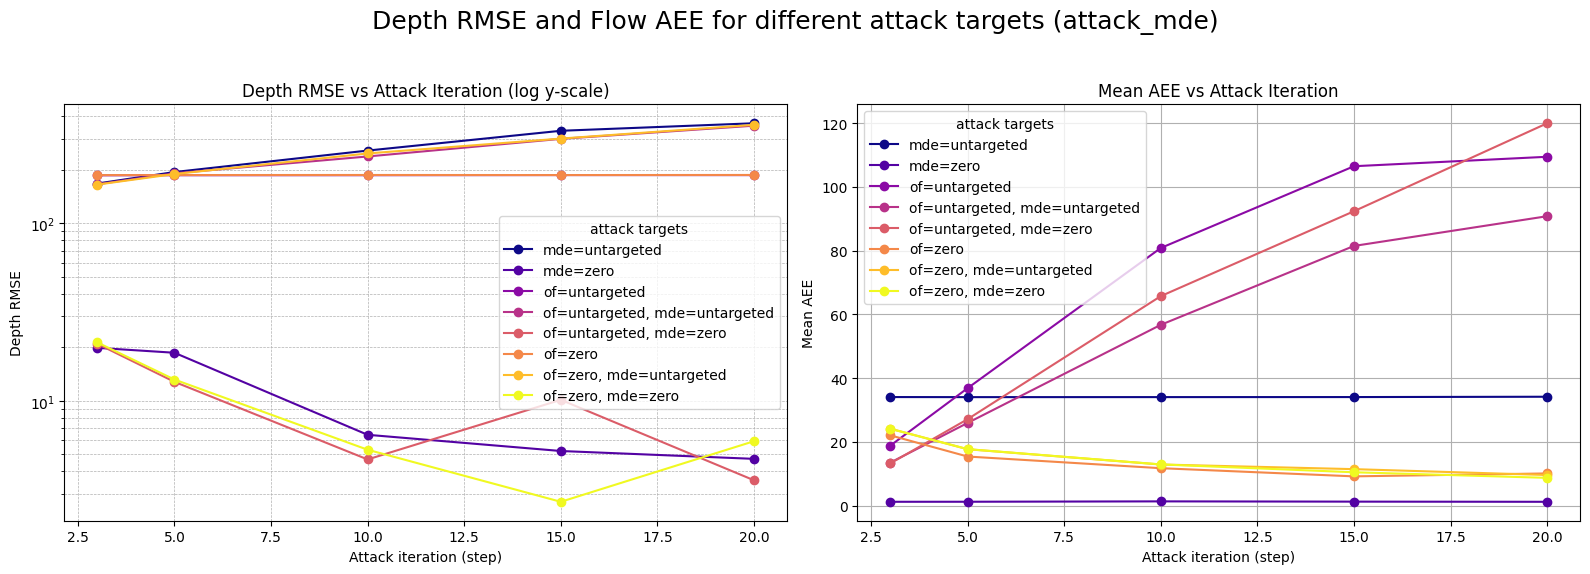

In [9]:
plot_depth_and_flow_by_attack_mde_targets(runs)